# Netflix Data Analysis

In [2]:
import pandas as pd

df = pd.read_csv("../data/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
#Basic overview
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   str           
 1   type          8807 non-null   str           
 2   title         8807 non-null   str           
 3   director      6173 non-null   str           
 4   cast          7982 non-null   str           
 5   country       7976 non-null   str           
 6   date_added    8709 non-null   datetime64[us]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   str           
 9   duration      8804 non-null   str           
 10  listed_in     8807 non-null   str           
 11  description   8807 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 825.8 KB


In [12]:
# Missing values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
#duplicates 
df.duplicated().sum()
df = df.drop_duplicates()

In [ ]:
# handling missing values 
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)

df = df.dropna(subset=['date_added', 'rating', 'duration'])

In [3]:
#date conversion
df['date_added'] = pd.to_datetime(df['date_added'],errors='coerce')

In [ ]:
#final check
df.isnull().sum()

## Summary
- Loaded and cleaned the Netflix dataset by handling missing values  
- Converted date_added to datetime format  
The dataset is now ready for further analysis.

In [6]:
#Extract year and month from date_added
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

df[['date_added', 'year_added', 'month_added']].head()

,date_added,year_added,month_added
0,2021-09-25,2021.0,9.0
1,2021-09-24,2021.0,9.0
2,2021-09-24,2021.0,9.0
3,2021-09-24,2021.0,9.0
4,2021-09-24,2021.0,9.0


In [11]:
#Extract numeric value from duration column
df['duration_int'] = df['duration'].str.extract(r'(\d+)')
df['duration_int'] = df['duration_int'].astype(float)     
df[['duration', 'duration_int']].head()

,duration,duration_int
0,90 min,90.0
1,2 Seasons,2.0
2,1 Season,1.0
3,1 Season,1.0
4,2 Seasons,2.0


In [10]:
#number of Movies vs TV Shows
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Matplotlib is building the font cache; this may take a moment.


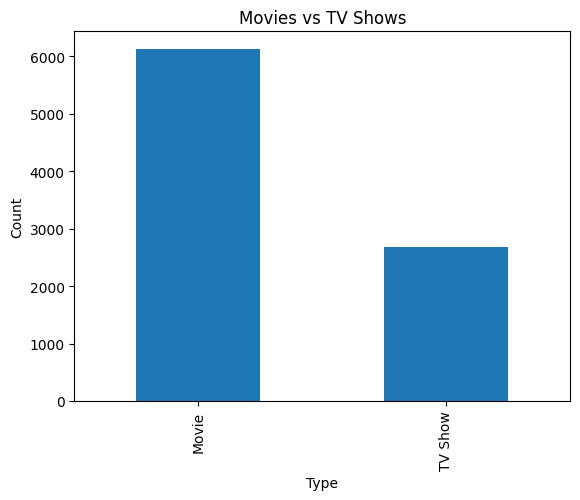

In [15]:
import matplotlib.pyplot as plt
# Plot bar chart
df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

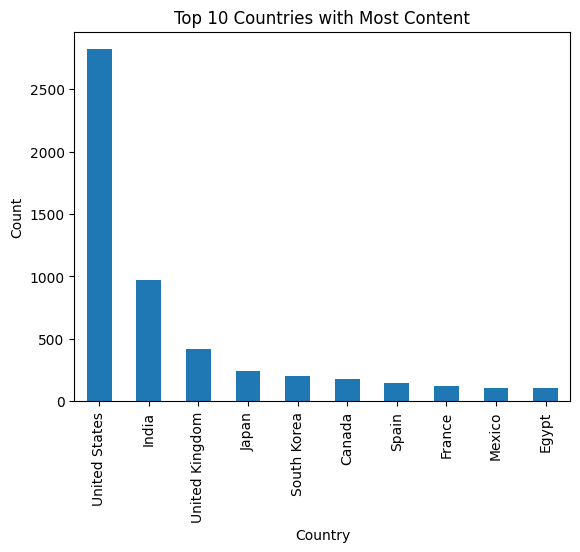

In [17]:
#Top 10 countries
top_countries = df['country'].value_counts().head(10)
top_countries.plot(kind='bar')

plt.title("Top 10 Countries with Most Content")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

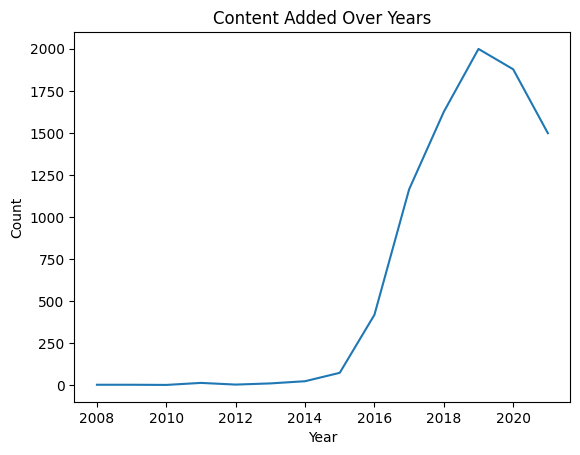

In [20]:
#Content added per year
df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

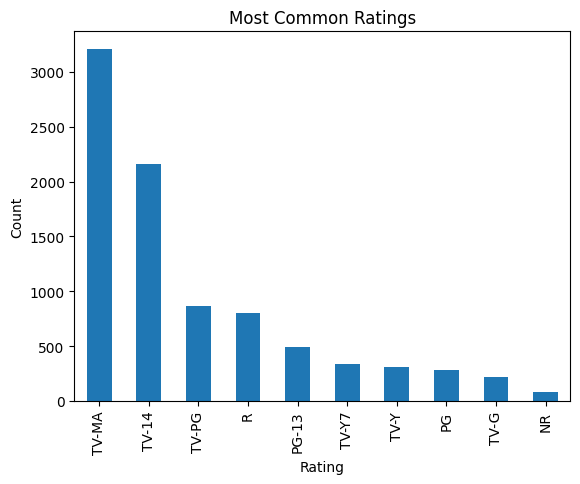

In [21]:
#Rating distribution
df['rating'].value_counts().head(10).plot(kind='bar')
plt.title("Most Common Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

## Summary

- Extracted date-based features (year, month)
- Cleaned duration column into numeric format
- Analyzed content type distribution
- Identified top countries and ratings
- Visualized trends using bar and line charts